# Chocolate Sales

In [1]:
import pandas as pd

### getting acquainted with the data

In [2]:
df = pd.read_csv('Chocolate Sales.csv')
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [3]:
f'rows: {df.shape[0]}, columns: {df.shape[1]}'

'rows: 3282, columns: 6'

In [4]:
df.dtypes

Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [6]:
df.describe()

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


In [7]:
df['Sales Person'].unique()

array(['Jehu Rudeforth', 'Van Tuxwell', 'Gigi Bohling', 'Jan Morforth',
       'Oby Sorrel', 'Gunar Cockshoot', 'Brien Boise',
       'Rafaelita Blaksland', 'Barr Faughny', 'Mallorie Waber',
       'Karlen McCaffrey', "Marney O'Breen", 'Beverie Moffet',
       'Roddy Speechley', 'Curtice Advani', 'Husein Augar', 'Kaine Padly',
       'Dennison Crosswaite', "Wilone O'Kielt", 'Andria Kimpton',
       'Kelci Walkden', 'Camilla Castle', 'Madelene Upcott',
       'Dotty Strutley', 'Ches Bonnell'], dtype=object)

In [8]:
df['Country'].unique()

array(['UK', 'India', 'Australia', 'New Zealand', 'USA', 'Canada'],
      dtype=object)

In [9]:
df.isna().any()

Sales Person     False
Country          False
Product          False
Date             False
Amount           False
Boxes Shipped    False
dtype: bool

### data cleaning

convert Amount column to float

In [10]:
df['Amount'] = df['Amount'].str.replace('[$,]', '', regex=True).astype(float)
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,5320.00,180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,7896.00,94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,4501.00,91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,12726.00,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,13685.00,184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,5303.58,354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,7339.32,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,2504.62,397


convert Date column to date

In [11]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.00,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.00,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.00,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.00,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.00,184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303.58,354
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339.32,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616.09,238
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504.62,397


### new columns

In [12]:
df['month']   = df['Date'].dt.to_period('M')
df['quarter'] = df['Date'].dt.to_period('Q')
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,month,quarter
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.00,180,2022-01,2022Q1
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.00,94,2022-08,2022Q3
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.00,91,2022-07,2022Q3
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.00,342,2022-04,2022Q2
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.00,184,2022-02,2022Q1
...,...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303.58,354,2024-05,2024Q2
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339.32,121,2024-06,2024Q2
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616.09,238,2024-07,2024Q3
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504.62,397,2024-07,2024Q3


In [13]:
df['amount_per_box'] = df['Amount'] / df['Boxes Shipped']
df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,month,quarter,amount_per_box
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.00,180,2022-01,2022Q1,29.555556
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.00,94,2022-08,2022Q3,84.000000
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.00,91,2022-07,2022Q3,49.461538
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.00,342,2022-04,2022Q2,37.210526
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.00,184,2022-02,2022Q1,74.375000
...,...,...,...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303.58,354,2024-05,2024Q2,14.981864
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339.32,121,2024-06,2024Q2,60.655537
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616.09,238,2024-07,2024Q3,2.588613
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504.62,397,2024-07,2024Q3,6.308866


In [14]:
print(f'Total amount: {df["Amount"].sum():.2f}')
print(f'Time interval: {df["Date"].min().date()} - {df["Date"].max().date()}')

Total amount: 19791571.86
Time interval: 2022-01-03 - 2024-08-31


In [15]:
df.dtypes

Sales Person              object
Country                   object
Product                   object
Date              datetime64[ns]
Amount                   float64
Boxes Shipped              int64
month                  period[M]
quarter            period[Q-DEC]
amount_per_box           float64
dtype: object

### summary statitstics of dataset

In [16]:
summary = pd.DataFrame({
    'Total amount': [f'{df["Amount"].sum():.2f}'],
    'Boxes sold' : [f'{df["Boxes Shipped"].sum()}'],
    'Transactions' : [f"{len(df):,}"],
    'Sales persons amount' : [df['Sales Person'].nunique()],
    'Countries' : [df['Country'].nunique()],
    'Products' : [df['Product'].nunique()],
    'Time interval': [f'{df["Date"].min().date()} - {df["Date"].max().date()}']
})
summary.T.rename(columns={0:'Value'})


,Value
Total amount,19791571.86
Boxes sold,540437
Transactions,"3,282"
Sales persons amount,25
Countries,6
Products,22
Time interval,2022-01-03 - 2024-08-31


### top salespersons

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
BROWN = '#5E310D'
ORANGE = '#F7910B'
SHADES_OF_BROWN = [ '#260903','#422009','#5E310D','#763C0C','#8D480B', '#A5530A' ]

In [18]:
top_salespersons = (df.groupby('Sales Person')['Amount']
            .sum()
            .sort_values(ascending=True)
            .tail(10))
top_salespersons

Sales Person
Marney O'Breen          836427.63
Kaine Padly             849062.76
Beverie Moffet          892421.37
Dennison Crosswaite     931849.57
Van Tuxwell             974425.09
Brien Boise             997326.48
Kelci Walkden          1002929.10
Madelene Upcott        1010028.72
Oby Sorrel             1017204.12
Ches Bonnell           1022599.96
Name: Amount, dtype: float64

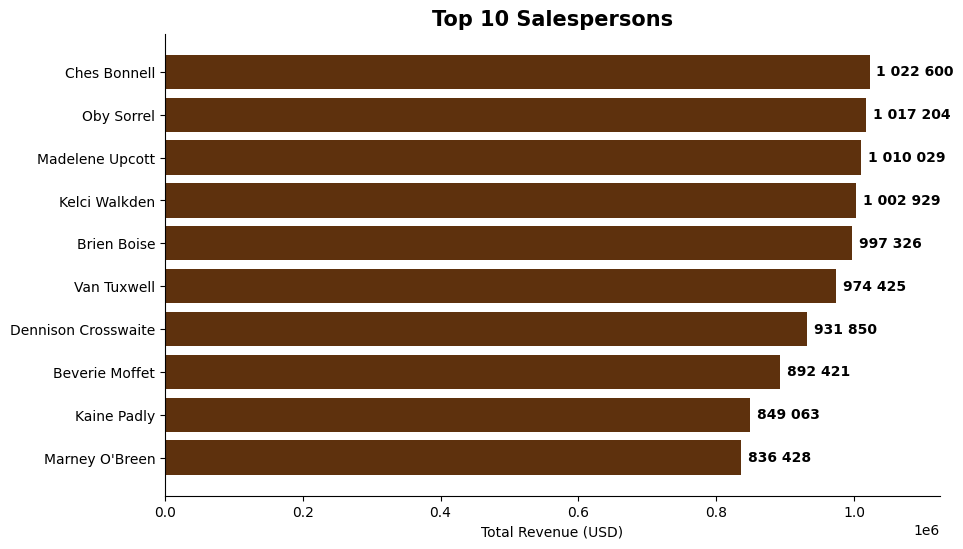

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_salespersons.index, top_salespersons.values, color = BROWN)
ax.bar_label(bars, labels=[f'{v:,.0f}'.replace(',',' ') for v in top_salespersons.values], padding=5, fontweight='bold')
ax.set_title('Top 10 Salespersons', fontweight='bold',  fontsize=15)
ax.set_xlabel('Total Revenue (USD)')
ax.set_xlim(0, top_salespersons.max() * 1.1)
ax.spines[['top', 'right']].set_visible(False)
plt.show()



### Revenue and sold boxes by country

In [20]:
country_revenue = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)
country_revenue

Country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: Amount, dtype: float64

In [21]:
country_boxes = df.groupby('Country')['Boxes Shipped'].sum().sort_values(ascending=False)
country_boxes

Country
Australia      99618
Canada         95158
UK             92523
India          89968
USA            81820
New Zealand    81350
Name: Boxes Shipped, dtype: int64

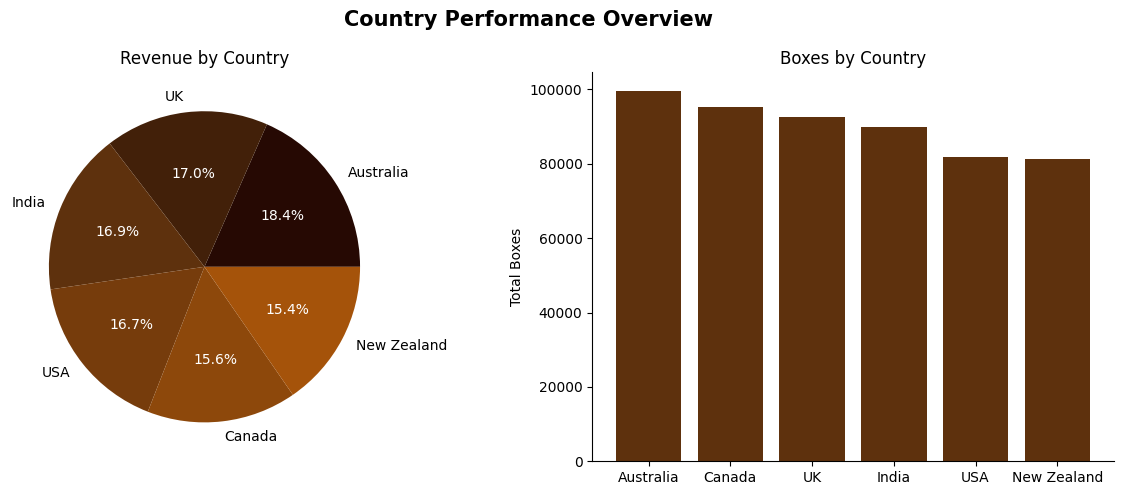

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title('Revenue by Country')
_, _, autotexts = axes[0].pie(country_revenue.values, 
            labels=country_revenue.index, 
            autopct='%1.1f%%',
            colors=SHADES_OF_BROWN, 
            )
[autotext.set_color('white') for autotext in autotexts]

axes[1].set_title('Boxes by Country')
axes[1].bar(country_boxes.index, country_boxes.values, color = BROWN)
axes[1].set_ylabel('Total Boxes')
axes[1].spines[['top', 'right']].set_visible(False)
# for tick in axes[1].get_xticklabels():
#     tick.set_rotation(30)

fig.suptitle('Country Performance Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Monthly revenues

In [25]:
monthly_revenues = df.groupby('month')['Amount'].sum().reset_index()
monthly_revenues

,month,Amount
0,2022-01,896105.00
1,2022-02,699377.00
2,2022-03,749483.00
3,2022-04,674051.00
4,2022-05,752892.00
5,2022-06,865144.00
6,2022-07,803425.00
7,2022-08,743148.00
8,2023-01,958985.77
9,2023-02,749617.46


In [26]:
monthly_revenues['date'] = monthly_revenues['month'].dt.to_timestamp()
monthly_revenues

,month,Amount,date
0,2022-01,896105.00,2022-01-01
1,2022-02,699377.00,2022-02-01
2,2022-03,749483.00,2022-03-01
3,2022-04,674051.00,2022-04-01
4,2022-05,752892.00,2022-05-01
5,2022-06,865144.00,2022-06-01
6,2022-07,803425.00,2022-07-01
7,2022-08,743148.00,2022-08-01
8,2023-01,958985.77,2023-01-01
9,2023-02,749617.46,2023-02-01


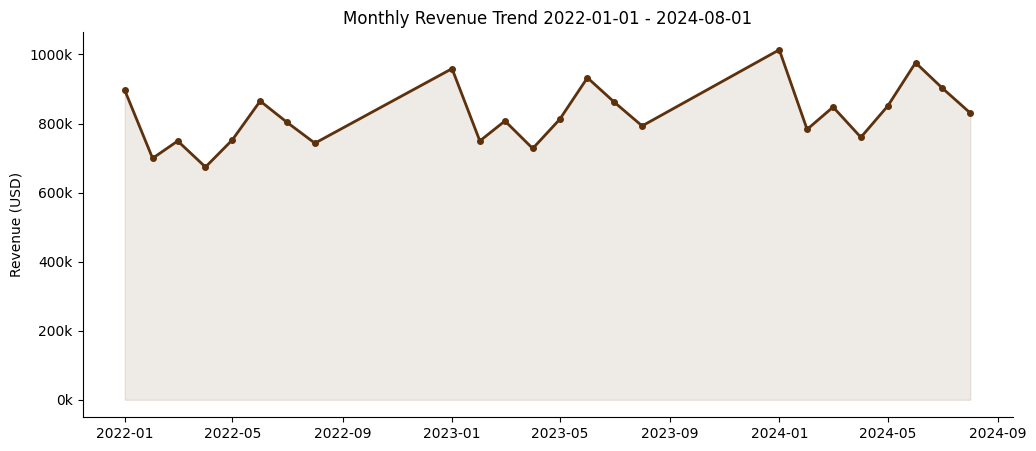

In [29]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title(f'Monthly Revenue Trend {monthly_revenues["date"].min().date()} - {monthly_revenues["date"].max().date()}')
ax.fill_between(monthly_revenues['date'], monthly_revenues['Amount'], alpha=0.1, color=BROWN)
ax.plot(monthly_revenues['date'], 
        monthly_revenues['Amount'], 
        color=BROWN, 
        linewidth=2, 
        marker='o',
        markersize=4)
ax.set_ylabel('Revenue (USD)')
ax.bar_label(bars, labels=[f'{v:,.0f}'.replace(',',' ') for v in top_salespersons.values], padding=5, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
ax.spines[['top', 'right']].set_visible(False)

plt.show()


### Top products

In [30]:
products = (df.groupby('Product')['Amount']
          .sum()
          .sort_values(ascending=True)
          .tail(10))
products

Product
Mint Chip Choco         904989.55
Spicy Special Slims     938131.69
Organic Choco Syrup     945345.73
85% Dark Bars           955268.24
99% Dark & Pure         960033.45
Eclairs                 996947.96
Peanut Butter Cubes    1036591.09
White Choc             1054257.00
50% Dark Bites         1087659.35
Smooth Sliky Salty     1120201.09
Name: Amount, dtype: float64

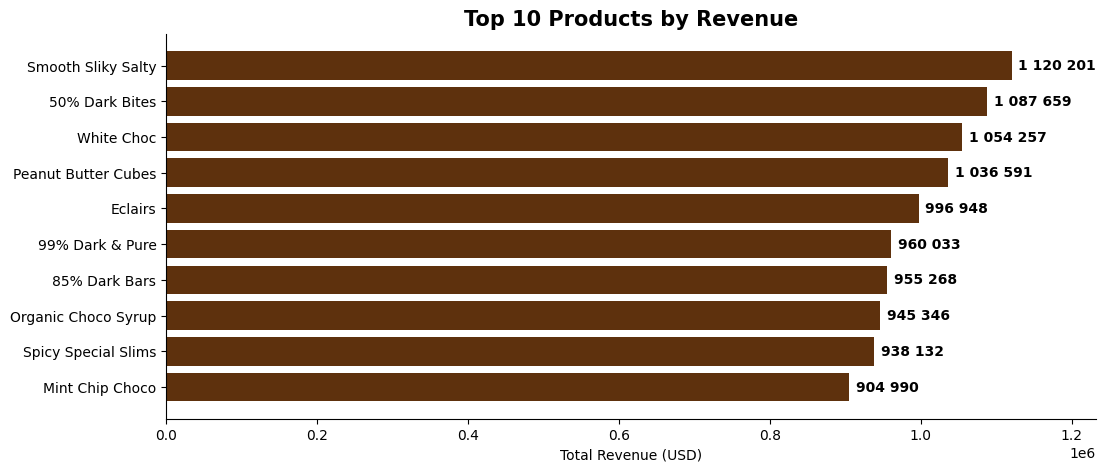

In [31]:
_, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Top 10 Products by Revenue', fontweight='bold',  fontsize=15)
bars = ax.barh(products.index, products.values, color=BROWN)
ax.bar_label(bars, 
             labels=[f'{v:,.0f}'.replace(',',' ') for v in products.values],
             padding=5, 
             fontweight='bold')
ax.set_xlabel('Total Revenue (USD)')
ax.set_xlim(0, products.max() * 1.1)
ax.spines[['top', 'right']].set_visible(False)
# plt.tight_layout()
plt.show()

### revenue heatmap - country and quarter

In [32]:
pivot = df.pivot_table(index='Country', columns='quarter', values='Amount', aggfunc='sum')
pivot

quarter,2022Q1,2022Q2,2022Q3,2023Q1,2023Q2,2023Q3,2024Q1,2024Q2,2024Q3
Country,,,,,,,,,
Australia,479220.0,390544.0,267603.0,518117.78,422655.47,286760.47,540540.35,441987.73,299015.55
Canada,407862.0,261534.0,293503.0,436018.02,282283.07,314193.59,460301.90,292660.67,330139.40
India,323351.0,398895.0,323554.0,347027.19,426354.91,343868.29,362388.89,455340.30,362951.25
New Zealand,395801.0,363993.0,190624.0,425818.41,394019.53,205316.16,444511.78,410766.19,212803.97
UK,393953.0,469336.0,188503.0,419706.45,509188.96,200029.15,445448.77,527849.10,211374.47
USA,344778.0,407785.0,282786.0,369409.71,437818.73,304792.07,391324.53,458598.07,316565.98


In [33]:
pivot.columns = [str(c) for c in pivot.columns]

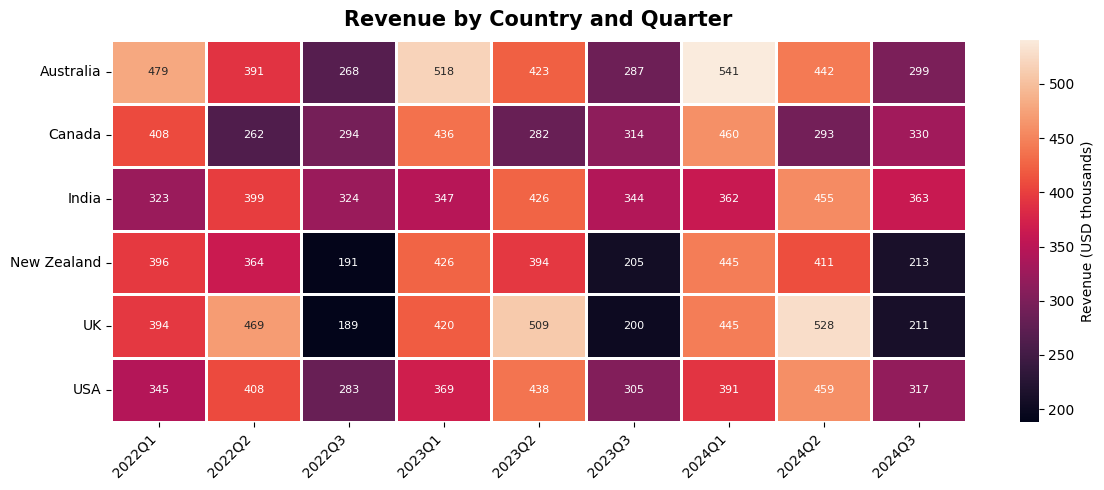

In [34]:
_, ax = plt.subplots(figsize=(12, 5))

ax.set_title('Revenue by Country and Quarter', fontweight='bold',  fontsize=15, pad=10)

sns.heatmap(pivot / 1000, annot=True, fmt='.0f', 
            linewidths=1, ax=ax,
            annot_kws={'size': 8},
            cbar_kws={'label': 'Revenue (USD thousands)'})
ax.set_ylabel('')
ax.set_xlabel('')
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha('right')
for tick in ax.get_yticklabels():
    tick.set_rotation(360)
plt.tight_layout()
plt.show()

### ABC groups

In [35]:
import numpy as np

def abc_groups(df, index):
    '''function for ABC analysis
    Args:
        df (dataframe): dataframe must have only index column and columns to aggregate
        index: name of index column

    Returns:
        dataframe: dataframe where  items of index columns have assigned groups
    '''
    columns = list(df.columns)
    columns.remove(index)
    groupped_df = df.groupby(index).agg({column: 'sum' for column in columns})
    for column in columns:
        groupped_df[f'rel_{column}'] = groupped_df[column] / sum(groupped_df[column])
        groupped_df = groupped_df.sort_values(f'rel_{column}', ascending=False)
        groupped_df[f'cumsum_{column}'] = groupped_df[f'rel_{column}'].cumsum()
        groupped_df[f'abc_{column}'] = np.where(groupped_df[f'cumsum_{column}'] < 0.4, 'A', 
                                                np.where(groupped_df[f'cumsum_{column}'] < 0.75, 'B', 'C')
                                                )
    return groupped_df[columns + [f'abc_{column}' for column in columns]]

In [36]:
df_for_abc=df[['Product', 'Amount', 'Boxes Shipped']]
abc_groups(df_for_abc, index='Product')

,Amount,Boxes Shipped,abc_Amount,abc_Boxes Shipped
Product,,,,
50% Dark Bites,1087659.35,29810,A,A
Smooth Sliky Salty,1120201.09,26969,A,A
Eclairs,996947.96,26678,A,A
Spicy Special Slims,938131.69,26662,B,A
Caramel Stuffed Bars,742516.15,26576,C,A
Drinking Coco,822245.57,26402,C,A
Milk Bars,866273.62,25436,B,A
Peanut Butter Cubes,1036591.09,25339,A,A
White Choc,1054257.00,25158,A,B


In [37]:
df_for_abc=df[['Sales Person', 'Amount', 'Boxes Shipped']]
abc_groups(df_for_abc, 'Sales Person')

,Amount,Boxes Shipped,abc_Amount,abc_Boxes Shipped
Sales Person,,,,
Karlen McCaffrey,713832.64,29553,B,A
Beverie Moffet,892421.37,28027,A,A
Dennison Crosswaite,931849.57,26862,A,A
Kelci Walkden,1002929.10,26605,A,A
Oby Sorrel,1017204.12,26390,A,A
Brien Boise,997326.48,24738,A,A
Marney O'Breen,836427.63,24595,B,A
Jan Morforth,706585.50,23360,B,A
Ches Bonnell,1022599.96,23070,A,B


In [38]:
df_for_abc=df[['month', 'Amount', 'Boxes Shipped']]
abc_groups(df_for_abc, 'month')

,Amount,Boxes Shipped,abc_Amount,abc_Boxes Shipped
month,,,,
2024-01,1013621.82,28438,A,A
2023-01,958985.77,28189,A,A
2022-01,896105.00,27535,A,A
2023-06,932625.17,27056,A,A
2024-06,976162.77,27041,A,A
2022-06,865144.00,26260,A,A
2024-07,902250.63,23565,A,A
2023-07,861856.66,23367,A,A
2022-07,803425.00,22876,B,B


### What do we know for now?

1. Who is the best sales person
2. Which products generate most revenue
3. All countries make a comparable contribution to the final chocolate pie of revenue, with leading Australia and UK
4. Seasonal spikes before holiday season are visible.
5. The worst month is april for 3 years in a row.

to be continued...